# 07 — Marker positivity: what the data actually looks like

**Purpose: watch every step.** Nothing here is summarised for you — each cell prints or plots the
real numbers so you can check them against the images yourself.

This notebook works on **one donor and one marker at a time**, on the **full cell population**.
There is **no subsampling anywhere**. Set the parameters in the next cell and run top to bottom.

It walks through:
1. load the donor, full population
2. look at the marker's distribution
3. what the shipped preprocessing does to that distribution
4. clustering attempts, including the ones that fail
5. finding the boundary between the two populations
6. the same measurement across every donor


In [1]:
# ---- PARAMETERS -------------------------------------------------------------
DONOR     = '6566'          # T1D; maintainer's image count for INS here is ~200-400 cells
MARKER    = 'INS'           # the marker whose positive cells we are trying to identify
REFERENCE = 'Pan_Cytokeratin'   # the mutually-exclusive partner (only used in the 2-D steps)
# -----------------------------------------------------------------------------
import sys, glob, pathlib, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

REPO = pathlib.Path.cwd().resolve().parents[1]      # Islet-Explorer-Senior (data/ lives here)
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # make `phenocycler` importable
print('repo:', REPO)
print('REDSEA cells:', REPO/'data'/'cells_redsea')


repo: /home/smith6jt/IO60panc2nd/Islet-Explorer-Senior
REDSEA cells: /home/smith6jt/IO60panc2nd/Islet-Explorer-Senior/data/cells_redsea


## Step 1 — load the donor, every cell

`data/cells_redsea/` holds the REDSEA spillover-corrected whole-cell means — the values the
positivity call is made on. We load **all** of them.


In [2]:
f = glob.glob(str(REPO/'data'/'cells_redsea'/f'donor_id={DONOR}'/'*.parquet'))[0]
d = pd.read_parquet(f, columns=[MARKER, REFERENCE])
X = d.to_numpy(float)
X = X[np.isfinite(X).all(1) & (X >= 0).all(1)]
v = X[:, 0]                                  # the target marker
print(f'donor {DONOR}: {len(X):,} cells   (no subsampling)')
print(d.describe().T[['count','mean','50%','max']])


donor 6566: 1,781,276 cells   (no subsampling)
                     count        mean         50%           max
INS              1781276.0   13.168036   10.029693   9526.771482
Pan_Cytokeratin  1781276.0  880.840737  447.942969  17177.085775


## Step 2 — look at the distribution

Log scale, because the values span four orders of magnitude. Look for **two populations**: the
dim bulk, and a separate bright group. If you can see them apart here, so should any method.


In [3]:
pos = v[v > 0]                     # REDSEA clamps some cells to exactly 0; not a mode, drop for the log view
lv  = np.log10(pos)
h, e = np.histogram(lv, bins=60, range=(lv.min(), lv.max()))
c = 0.5*(e[:-1]+e[1:])
print(f'{"INS range":>22} | {"cells":>9}')
for i in range(len(h)):
    bar = '#' * int(60*h[i]/max(h.max(),1))
    print(f'{10**e[i]:9.1f} - {10**e[i+1]:9.1f} | {h[i]:9,} {bar}')
print(f'\ncells exactly 0 (REDSEA clamp): {(v==0).sum():,}  ({(v==0).mean()*100:.2f}%)')


             INS range |     cells
      0.0 -       0.0 |         2 
      0.0 -       0.0 |         0 
      0.0 -       0.0 |         0 
      0.0 -       0.0 |         2 
      0.0 -       0.0 |         0 
      0.0 -       0.0 |         3 
      0.0 -       0.0 |         1 
      0.0 -       0.0 |         4 
      0.0 -       0.0 |         2 
      0.0 -       0.0 |         8 
      0.0 -       0.0 |         7 
      0.0 -       0.0 |        15 
      0.0 -       0.0 |        11 
      0.0 -       0.0 |        20 
      0.0 -       0.0 |        33 
      0.0 -       0.0 |        40 
      0.0 -       0.0 |        52 
      0.0 -       0.0 |        85 
      0.0 -       0.0 |       142 
      0.0 -       0.0 |       189 
      0.0 -       0.0 |       234 
      0.0 -       0.0 |       376 
      0.0 -       0.0 |       547 
      0.0 -       0.0 |       734 
      0.0 -       0.0 |     1,017 
      0.0 -       0.1 |     1,365 
      0.1 -       0.1 |     1,840 
      0.1 -       0.


cells exactly 0 (REDSEA clamp): 47,385  (2.66%)


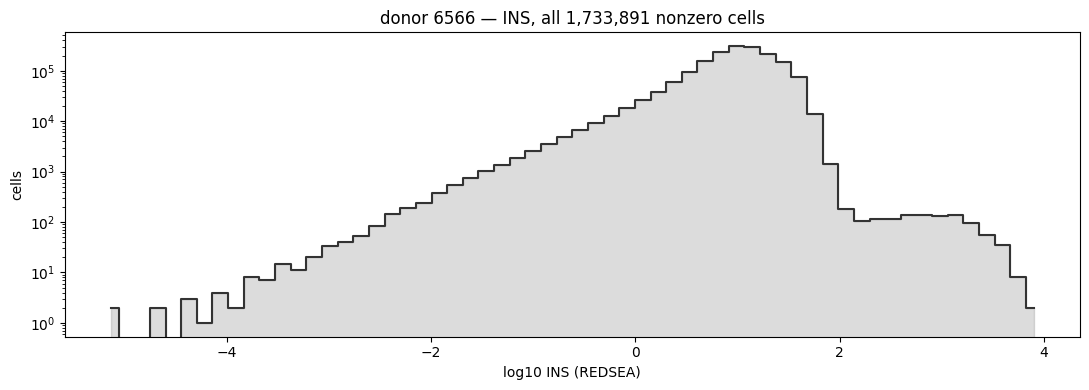

In [4]:
fig, ax = plt.subplots(figsize=(11,4))
ax.step(c, h, where='mid', color='#333')
ax.fill_between(c, h, step='mid', alpha=.25, color='#777')
ax.set_yscale('log'); ax.set_xlabel(f'log10 {MARKER} (REDSEA)'); ax.set_ylabel('cells')
ax.set_title(f'donor {DONOR} — {MARKER}, all {len(pos):,} nonzero cells')
plt.tight_layout(); plt.show()


## Step 3 — what the shipped preprocessing does to it

`robust_minmax_scale` clips at the 0.5th and 99.5th percentiles before the clusterer sees the data.
Everything above the upper clip becomes exactly 1.0. Check below how many cells that is, and
whether the bright population you saw in step 2 survives it.


In [5]:
lo, hi = np.quantile(v, 0.005), np.quantile(v, 0.995)
n_flat = int((v > hi).sum())
print(f'lower clip (p0.5)  = {lo:.2f}')
print(f'upper clip (p99.5) = {hi:.2f}')
print(f'cells flattened to exactly 1.0 : {n_flat:,}  ({n_flat/len(v)*100:.3f}% of the tissue)')
print(f'brightest {MARKER} value in the donor : {v.max():.1f}   ({v.max()/hi:.0f}x the clip point)')
print('\n-> every cell above the clip is indistinguishable after scaling.')


lower clip (p0.5)  = 0.00
upper clip (p99.5) = 53.50
cells flattened to exactly 1.0 : 8,907  (0.500% of the tissue)
brightest INS value in the donor : 9526.8   (178x the clip point)

-> every cell above the clip is indistinguishable after scaling.


## Step 4 — clustering attempts, including the failures

Full data, log space, **no clipping and no subsampling** — i.e. the fair version. Watch the cluster
sizes: a method that works should produce one small cluster holding the bright population.


In [6]:
from sklearn import cluster, mixture
L = np.log10(X + 1)

def show(name, lab):
    rows = sorted(((int((lab==g).sum()), v[lab==g].mean(), v[lab==g].min(), v[lab==g].max())
                   for g in np.unique(lab)), key=lambda r: -r[1])
    print(f'{name}')
    for n, mu, mn, mx in rows:
        print(f'    n={n:>9,}   mean {MARKER} {mu:9.1f}   range {mn:8.1f} - {mx:9.1f}')

for k in (2, 3, 4):
    show(f'GMM k={k}  (1-D, {MARKER})',
         mixture.GaussianMixture(k, n_init=3, random_state=0).fit_predict(L[:, [0]]))
show('KMeans k=2', cluster.KMeans(2, n_init=10, random_state=0).fit_predict(L[:, [0]]))


GMM k=2  (1-D, INS)
    n=1,435,175   mean INS      15.1   range      4.2 -     169.5
    n=  346,101   mean INS       5.0   range      0.0 -    9526.8


GMM k=3  (1-D, INS)
    n=  663,943   mean INS      24.6   range     12.9 -    9526.8
    n=  891,557   mean INS       7.7   range      2.7 -      12.9
    n=  225,776   mean INS       1.1   range      0.0 -       2.7


GMM k=4  (1-D, INS)
    n=  426,172   mean INS      30.0   range     17.3 -    9526.8
    n=  777,621   mean INS      11.2   range      6.7 -      17.3
    n=  420,847   mean INS       4.4   range      1.7 -       6.7
    n=  156,636   mean INS       0.6   range      0.0 -       1.7


KMeans k=2
    n=1,215,337   mean INS      17.8   range      6.6 -    9526.8
    n=  565,939   mean INS       3.3   range      0.0 -       6.6


**Read the cluster sizes.** Variance-minimising clusterers put their components where the *mass*
is, so they carve the bulk into slabs of hundreds of thousands of cells and never isolate the
bright group. Raising k just makes more bulk slabs. The bright population is roughly **uniform in
log space**, which a Gaussian mixture cannot represent however many components it is given.


## Step 5 — find the boundary between the two populations

The separation is a **gap**, not a density peak. So: find the bulk's mode, then walk right to the
first local minimum in the smoothed density. That is the valley you can see in step 2.

No Otsu, no divisor, no input floor, and no assumption about how many cells should be positive —
the count is whatever this donor's own distribution gives.


In [7]:
from scipy.ndimage import uniform_filter1d

def valley(values, bins=160, smooth=7, depth=0.02):
    """Boundary between the dim bulk and the bright population, from one donor's own histogram.
    Returns (threshold, diagnostics). `depth` = how far below the bulk peak the minimum must sit."""
    p = values[values > 0]
    lp = np.log10(p)
    h, e = np.histogram(lp, bins=bins, range=(lp.min(), lp.max()))
    c = 0.5*(e[:-1]+e[1:])
    s = uniform_filter1d(h.astype(float), size=smooth)
    mode = int(np.argmax(s))
    for i in range(mode+3, len(s)-3):
        if s[i] <= s[i-1] and s[i] <= s[i+1] and s[i] < depth*s[mode]:
            return 10**c[i], dict(mode=10**c[mode], centers=c, smooth=s, mode_i=mode, anti_i=i)
    return np.nan, dict(mode=10**c[mode], centers=c, smooth=s, mode_i=mode, anti_i=None)

thr, dg = valley(v)
n_pos = int((v > thr).sum())
print(f'bulk mode          : {MARKER} ~ {dg["mode"]:.1f}')
print(f'valley (threshold) : {MARKER} ~ {thr:.1f}')
print(f'cells above it     : {n_pos:,}   ({n_pos/len(v)*100:.4f}% of the tissue)')


bulk mode          : INS ~ 11.9
valley (threshold) : INS ~ 219.5
cells above it     : 933   (0.0524% of the tissue)


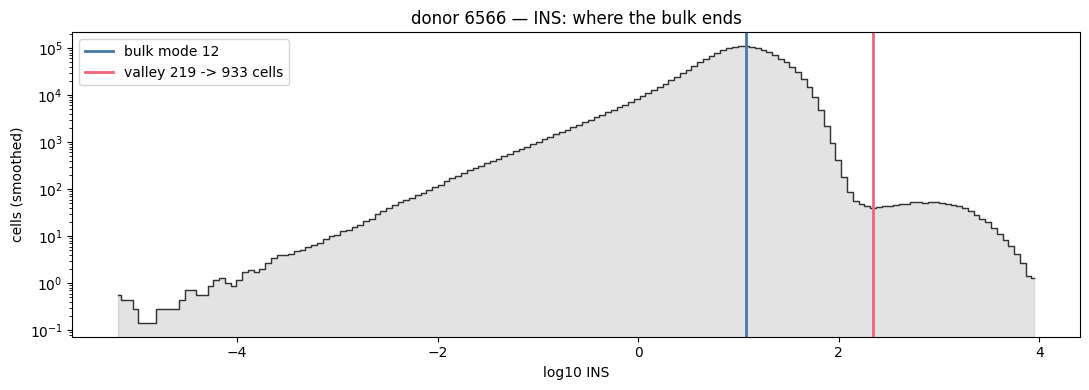

In [8]:
fig, ax = plt.subplots(figsize=(11,4))
ax.step(dg['centers'], dg['smooth'], where='mid', color='#333', lw=1)
ax.fill_between(dg['centers'], dg['smooth'], step='mid', alpha=.2, color='#777')
ax.axvline(np.log10(dg['mode']), color='#4477AA', lw=2, label=f'bulk mode {dg["mode"]:.0f}')
if np.isfinite(thr):
    ax.axvline(np.log10(thr), color='#EE6677', lw=2, label=f'valley {thr:.0f} -> {n_pos:,} cells')
ax.set_yscale('log'); ax.set_xlabel(f'log10 {MARKER}'); ax.set_ylabel('cells (smoothed)')
ax.set_title(f'donor {DONOR} — {MARKER}: where the bulk ends'); ax.legend()
plt.tight_layout(); plt.show()


### Check this against the image

Open donor `DONOR` in QuPath and look at the `MARKER` channel. The count printed above is the claim.
If it is wrong, the `depth` parameter of `valley()` is the knob — it sets how far below the bulk
peak the minimum has to fall before it counts as the boundary.


## Step 6 — the same measurement on every donor

One row per donor. The **threshold** should land in a similar intensity band across donors (it is
the same biological boundary); the **count** should vary with the biology (beta-cell loss in T1D).
That is the opposite of a quantile rule, which fixes the count and lets the threshold float.


In [9]:
rows = []
for p in sorted(glob.glob(str(REPO/'data'/'cells_redsea'/'donor_id=*'))):
    dn = p.split('donor_id=')[1]
    fp = glob.glob(p + '/*.parquet')[0]
    col = pd.read_parquet(fp, columns=[MARKER])[MARKER].to_numpy(float)
    col = col[np.isfinite(col) & (col >= 0)]
    t, g = valley(col)
    n = int((col > t).sum()) if np.isfinite(t) else -1
    rows.append(dict(donor=dn, n_cells=len(col), bulk_mode=round(g['mode'],1),
                     threshold=round(t,1) if np.isfinite(t) else np.nan,
                     n_positive=n, pct=round(n/len(col)*100, 4) if n >= 0 else np.nan))
    print(f"  {dn}: {rows[-1]['n_positive']:>8,} positive  (threshold {rows[-1]['threshold']})", flush=True)
out = pd.DataFrame(rows)
out


  115:   48,224 positive  (threshold 324.6)


  6374:   50,284 positive  (threshold 480.2)


  6380:       12 positive  (threshold 239.5)


  6436:    2,087 positive  (threshold 182.9)


  6442:   19,831 positive  (threshold 240.9)


...

  6566:      933 positive  (threshold 219.5)


  6591:    6,424 positive  (threshold 573.4)


  6593:   20,633 positive  (threshold 197.9)


  6623:       59 positive  (threshold 254.4)


,donor,n_cells,bulk_mode,threshold,n_positive,pct
0,115,860864,26.5,324.6,48224,5.6018
1,6374,2132190,34.0,480.2,50284,2.3583
2,6380,623782,8.4,239.5,12,0.0019
3,6436,1579443,3.6,182.9,2087,0.1321
4,6442,1419677,6.0,240.9,19831,1.3969
5,6450,368048,5.8,165.1,1991,0.5410
6,6461,1445032,6.3,370.6,29263,2.0251
7,6476,1625350,32.0,356.4,50821,3.1268
8,6482,1135669,22.9,467.9,31152,2.7431
9,6493,1227411,13.5,458.4,36106,2.9416


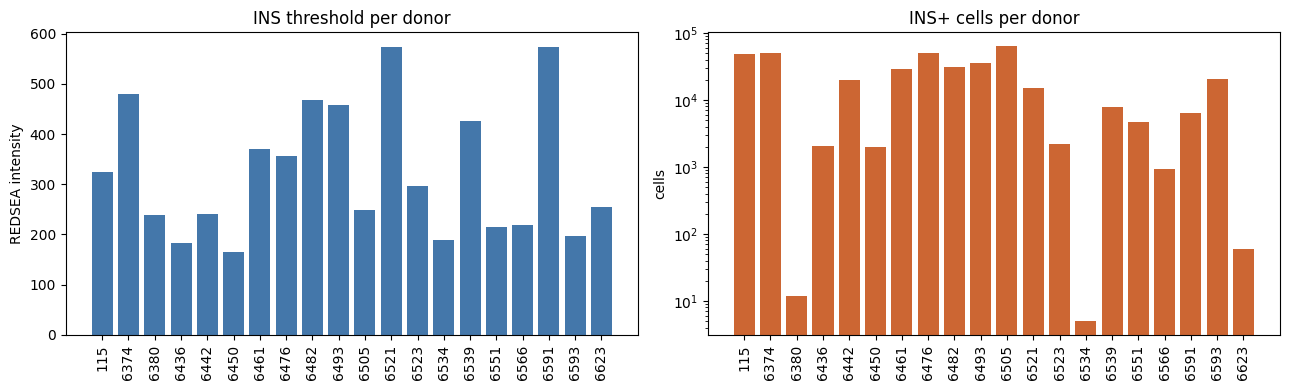

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax[0].bar(out.donor, out.threshold, color='#4477AA'); ax[0].set_title(f'{MARKER} threshold per donor')
ax[0].set_ylabel('REDSEA intensity'); ax[0].tick_params(axis='x', rotation=90)
ax[1].bar(out.donor, out.n_positive, color='#CC6633'); ax[1].set_yscale('log')
ax[1].set_title(f'{MARKER}+ cells per donor'); ax[1].set_ylabel('cells'); ax[1].tick_params(axis='x', rotation=90)
plt.tight_layout(); plt.show()


## What this notebook does not do

- It does **not** write anything to `data/`. It is a read-only investigation.
- It does **not** use the RESTORE divisor, the input floor, Otsu, or the reference marker for the
  threshold — only the target marker's own distribution on that donor.
- The threshold is a **claim to be checked against the images**, not a validated call.
